In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
Data = pd.read_csv('Cardiotocographic.csv')
Data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
Data.shape

(2126, 14)

In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
Data.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [9]:
Data.fillna({'LB':Data.LB.median(),
             'AC':Data.AC.median(),
             'DS':Data.DS.median(),
             'DP':Data.DP.median(),
             'MLTV':Data.MLTV.median(),
             'Width':Data.Width.median(),
             'Tendency':Data.Tendency.median(),
             'NSP':Data.NSP.median()},inplace=True)

In [10]:
Data.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [12]:
Data.duplicated().sum()

np.int64(2)

In [13]:
Data.drop_duplicates(inplace=True,ignore_index=True)

In [14]:
Data.duplicated().sum()

np.int64(0)

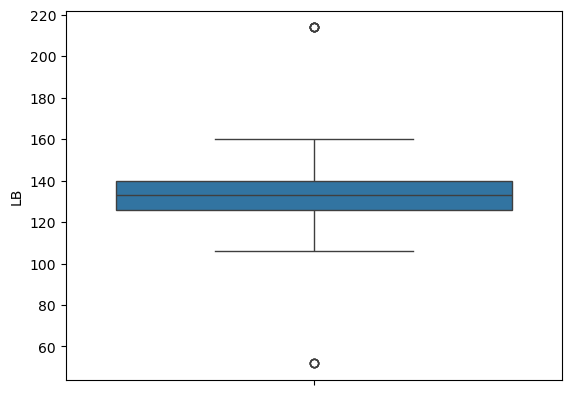

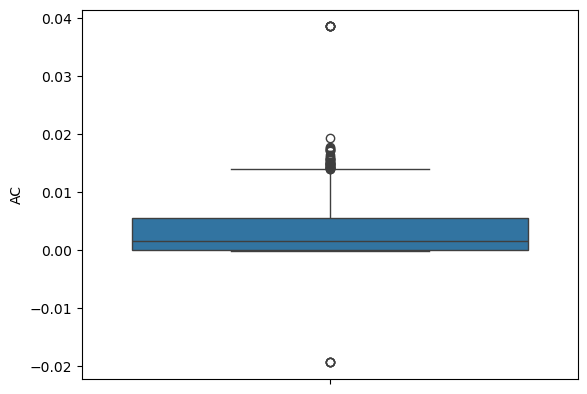

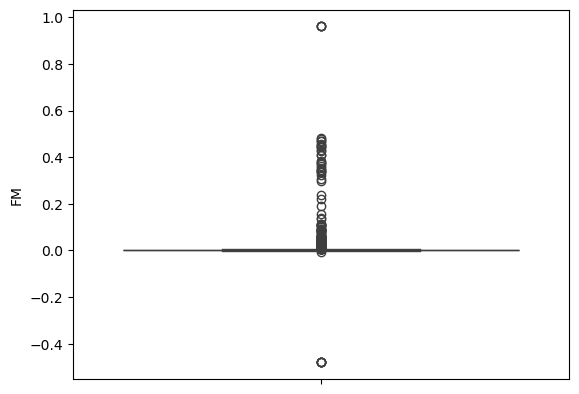

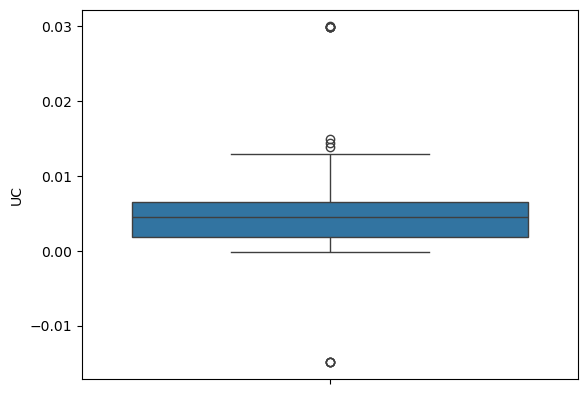

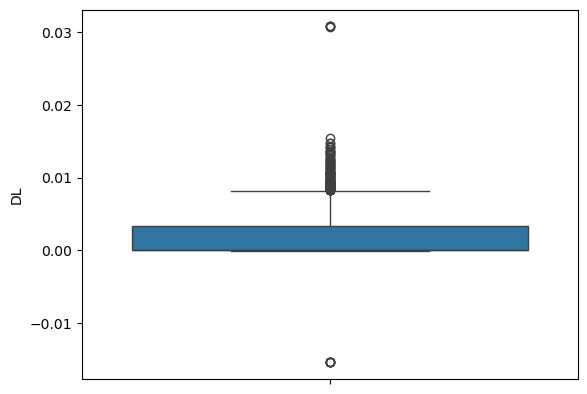

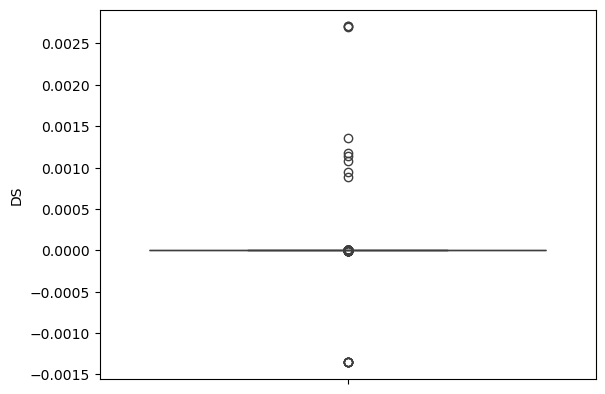

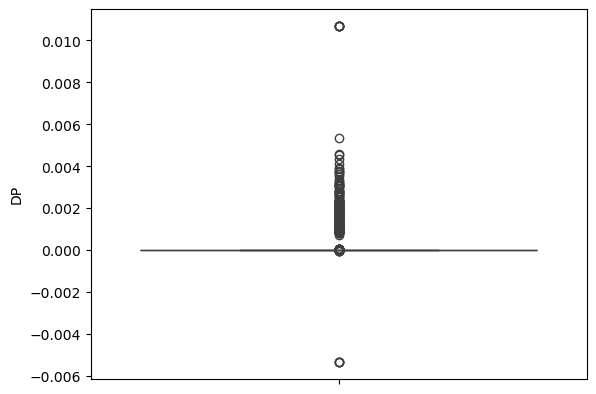

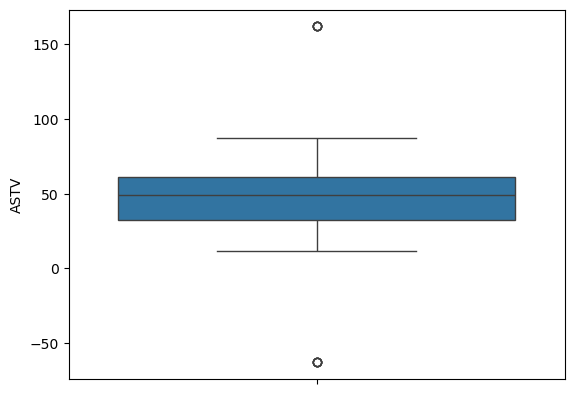

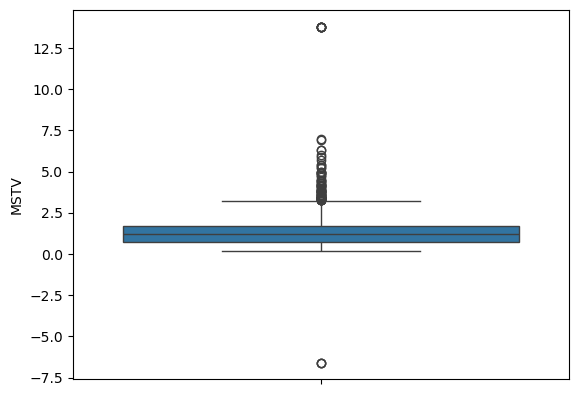

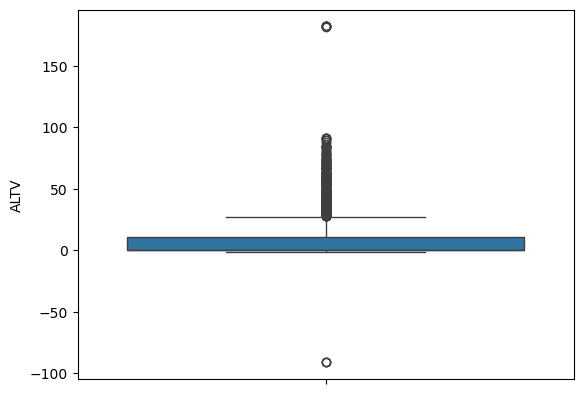

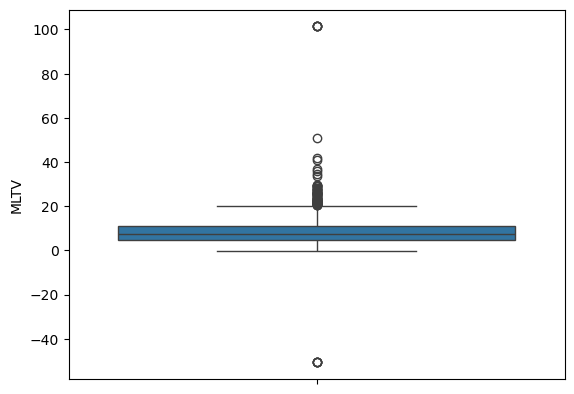

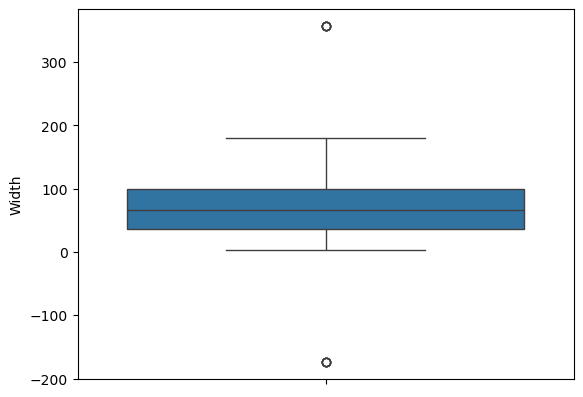

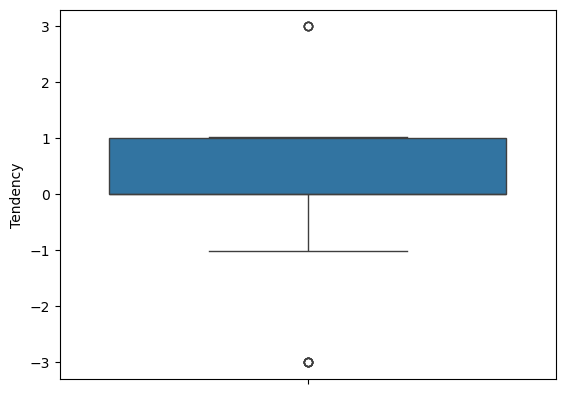

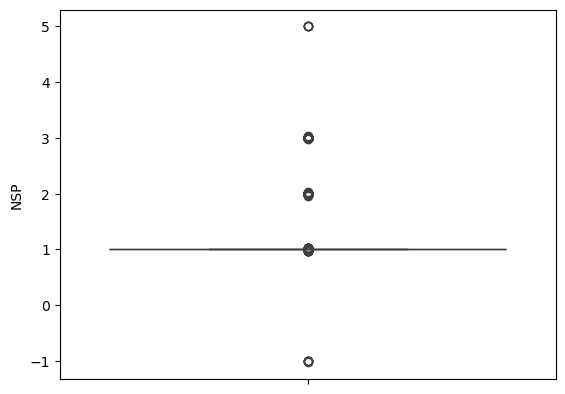

In [15]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

In [18]:
def outliers_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upperr_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upperr_extreme if x>upperr_extreme else x)
for col in Data.select_dtypes(include=['int','float']).columns:
    outliers_capping(Data,col)

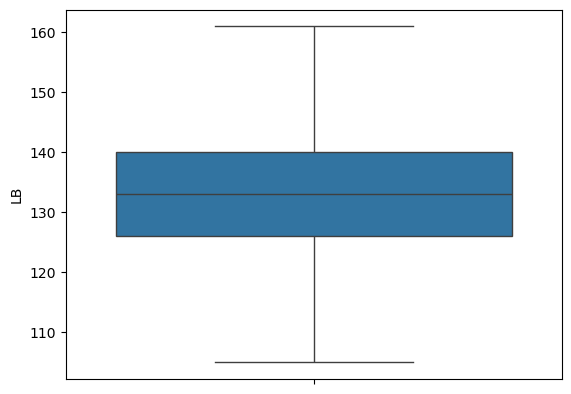

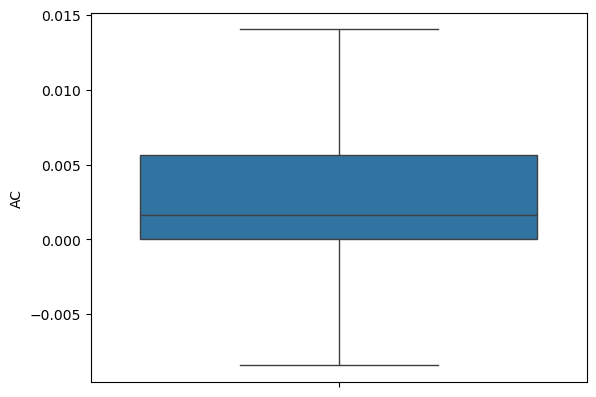

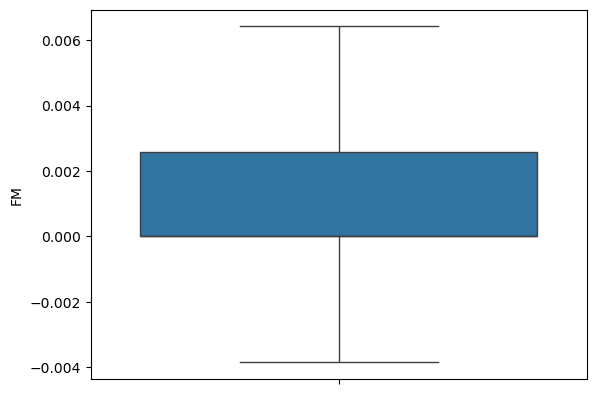

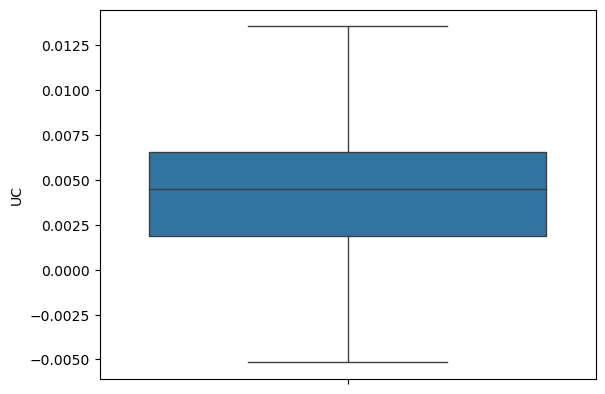

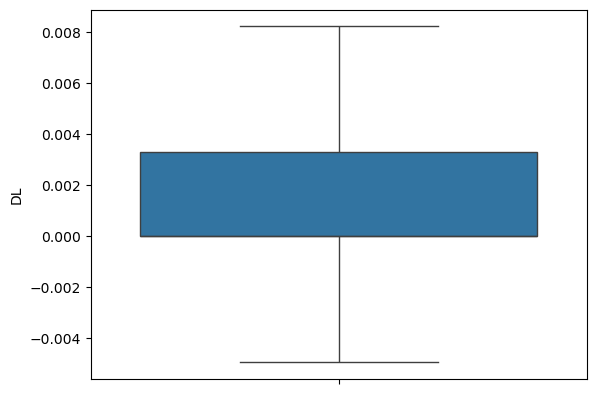

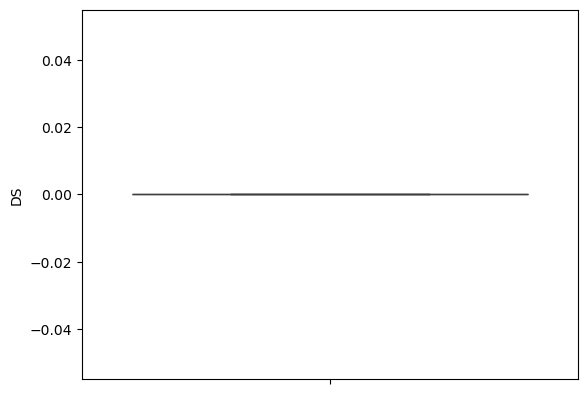

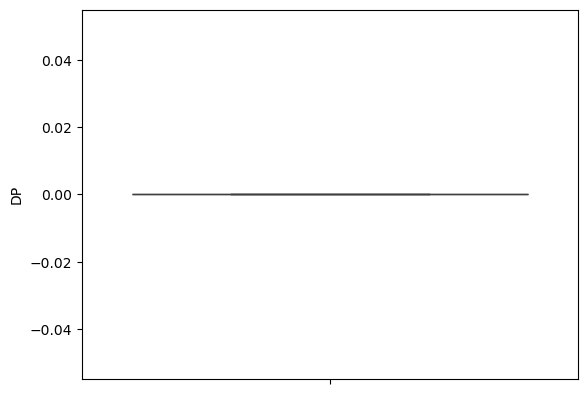

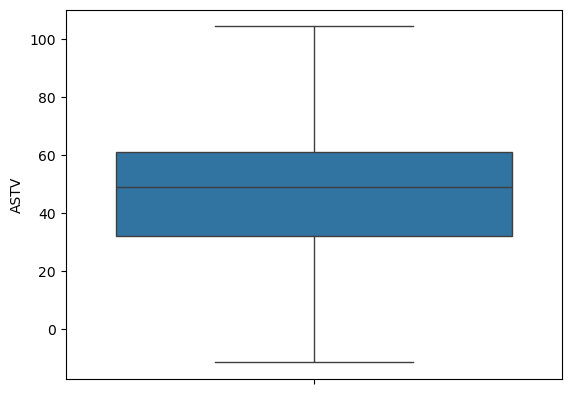

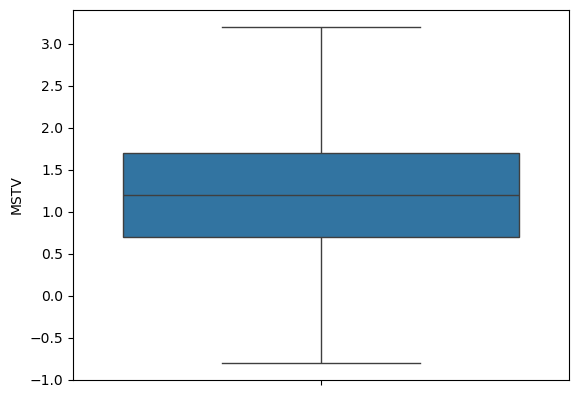

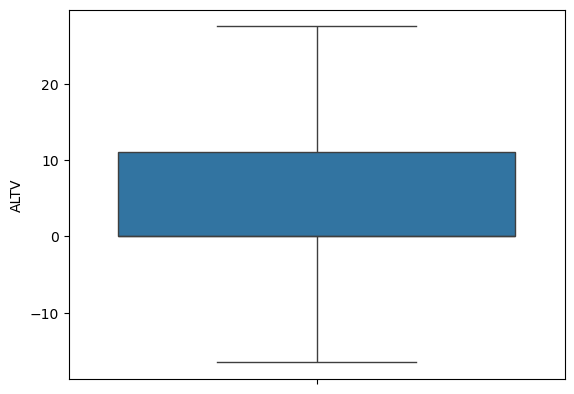

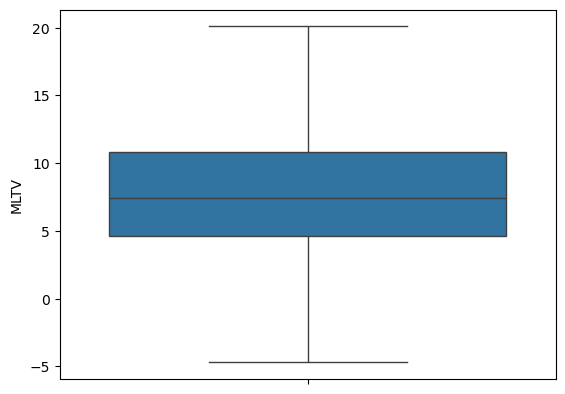

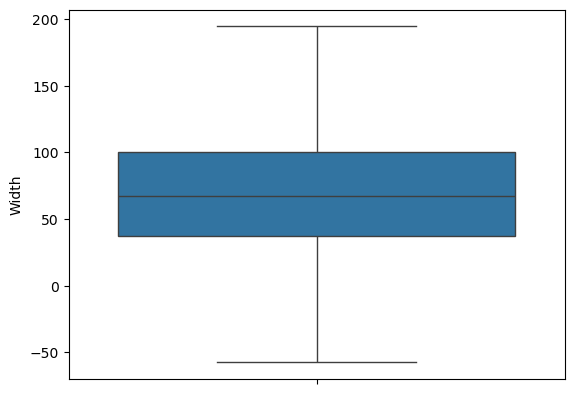

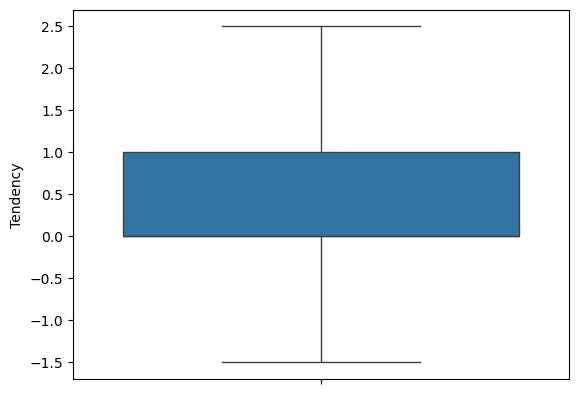

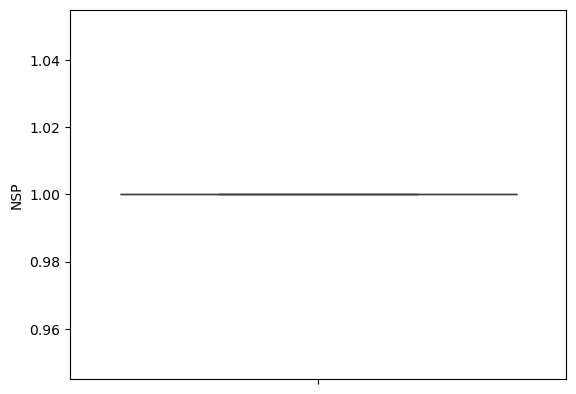

In [19]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

In [22]:
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2124.0,133.288721,9.926790,105.000000,126.000000,133.000000,140.000000,161.000000
AC,2124.0,0.003133,0.003830,-0.008418,0.000000,0.001634,0.005612,0.014030
FM,2124.0,0.001570,0.002487,-0.003853,0.000000,0.000000,0.002568,0.006421
UC,2124.0,0.004365,0.003001,-0.005158,0.001858,0.004486,0.006536,0.013552
DL,2124.0,0.001772,0.002670,-0.004938,0.000000,0.000000,0.003292,0.008230
DS,2124.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DP,2124.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASTV,2124.0,46.998334,17.609911,-11.500000,32.000000,49.000000,61.000000,104.500000
MSTV,2124.0,1.304554,0.781303,-0.800000,0.700000,1.200000,1.700000,3.200000
ALTV,2124.0,6.697979,10.381254,-16.500000,0.000000,0.000000,11.000000,27.500000


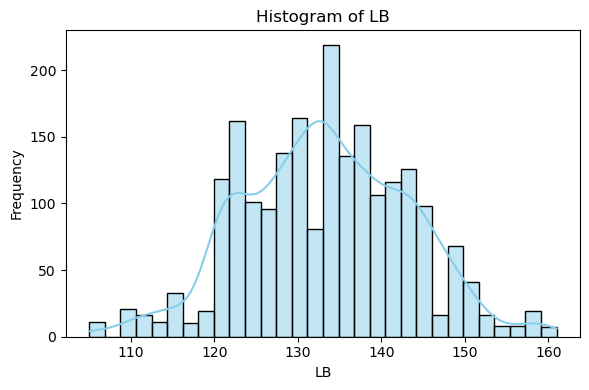

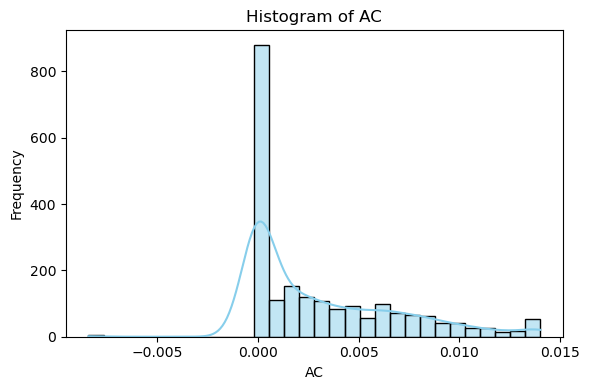

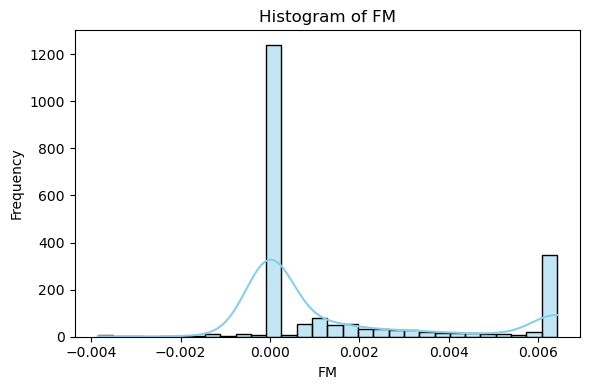

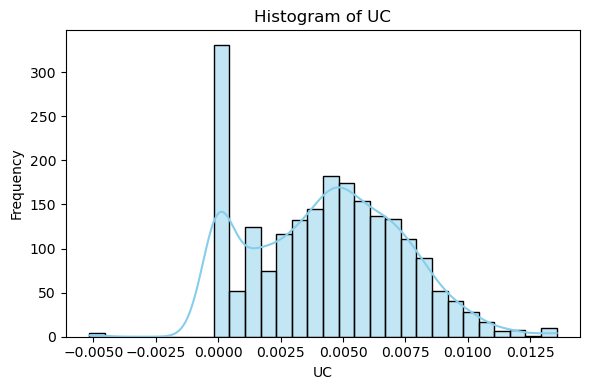

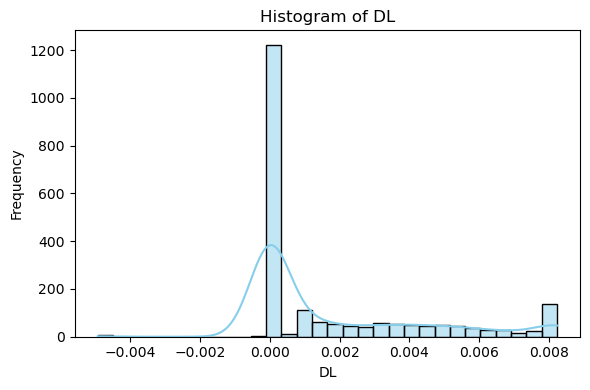

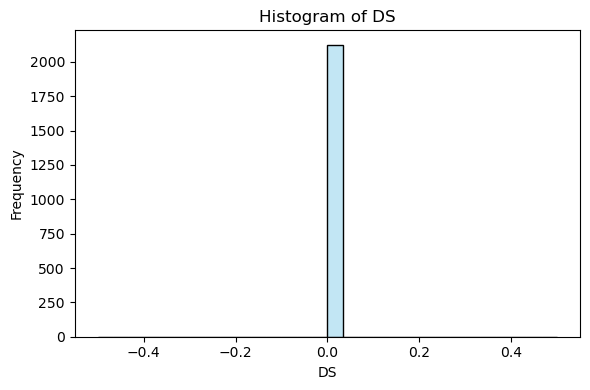

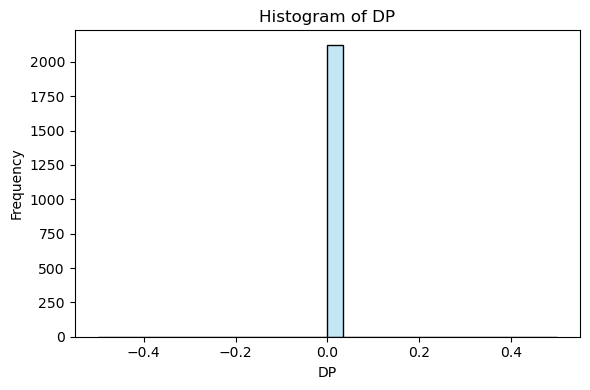

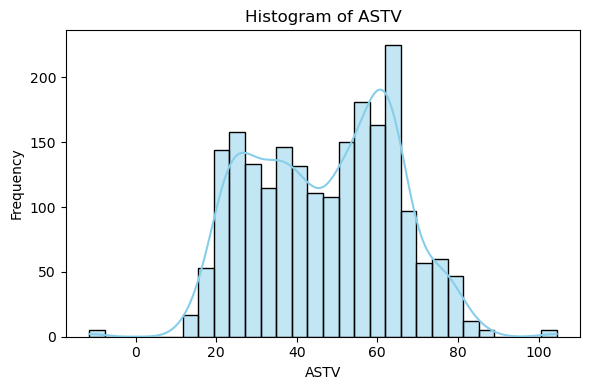

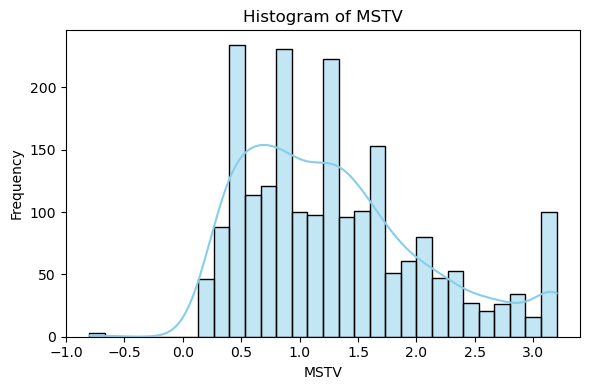

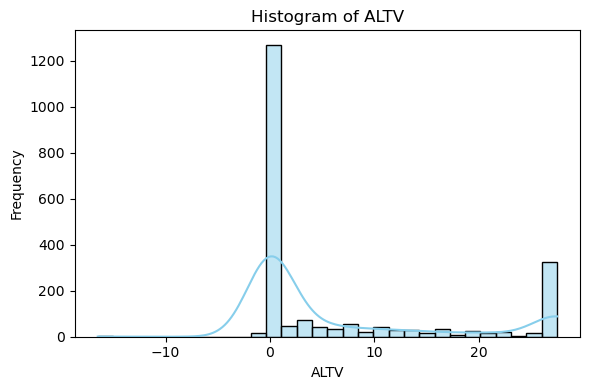

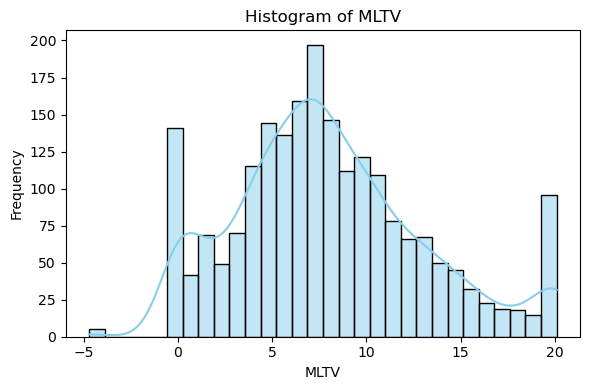

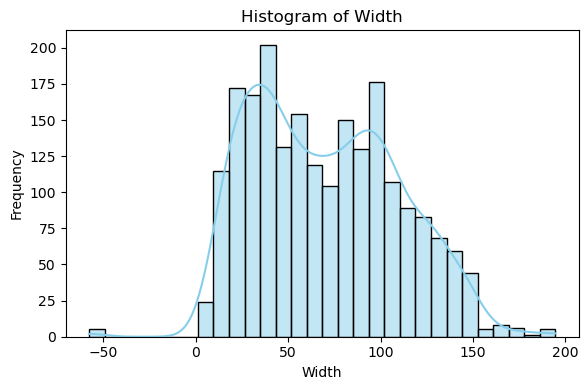

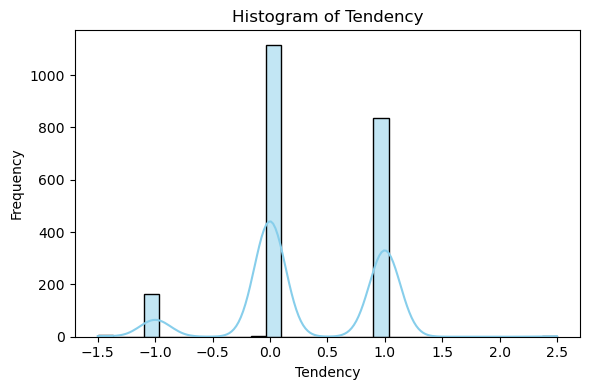

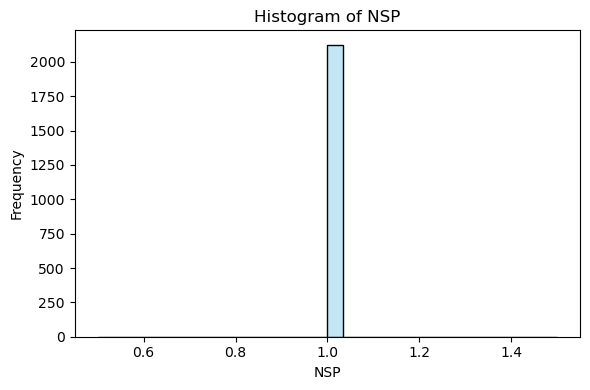

In [28]:
for col in Data:
    plt.figure(figsize=(6,4))
    sns.histplot(Data[col],kde=True,bins=30,color='skyblue')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

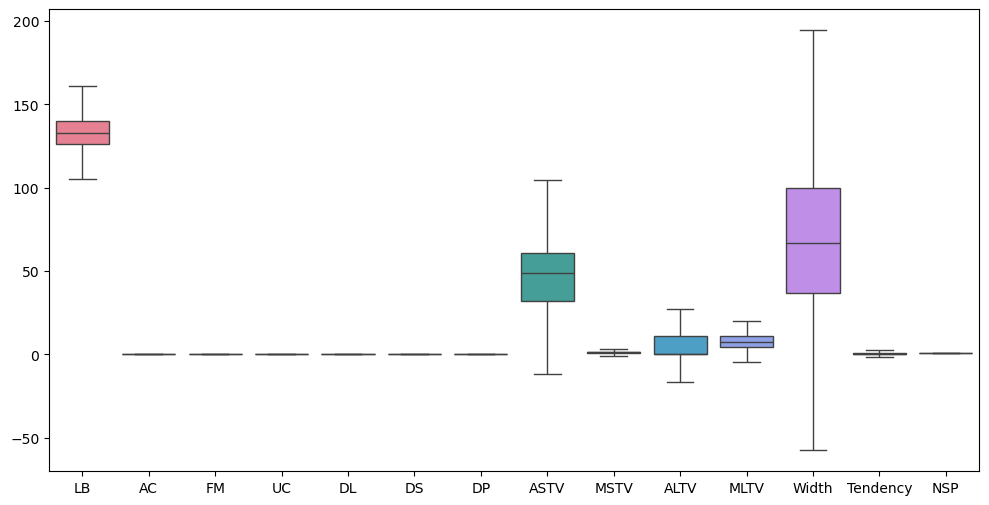

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(data=Data)
plt.show()

In [32]:
# The dataset does not contain any categorical variables. All features are numerical in nature; therefore, bar charts or pie charts were 
# not applicable for this dataset.

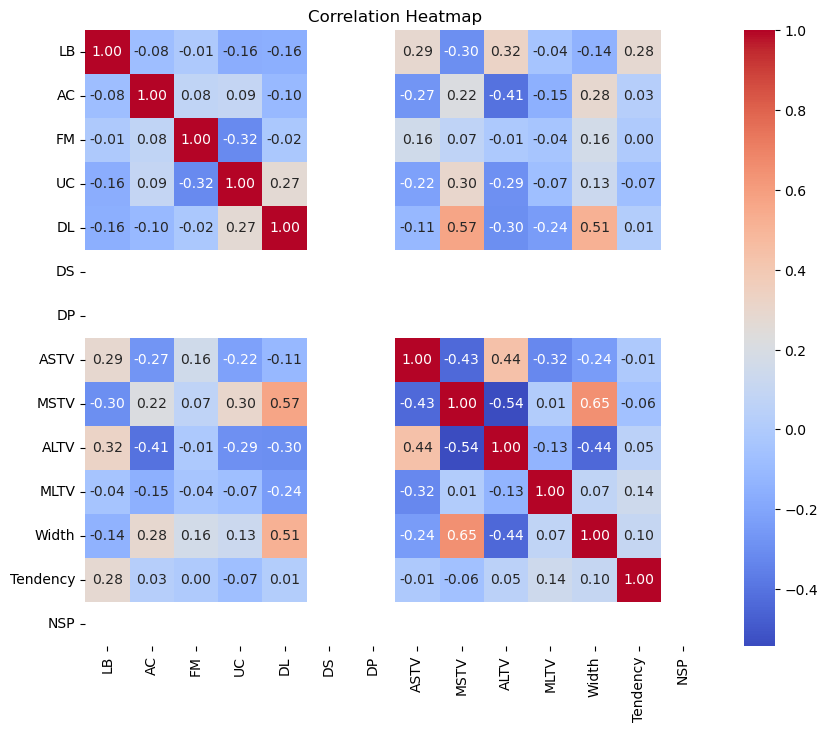

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(Data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

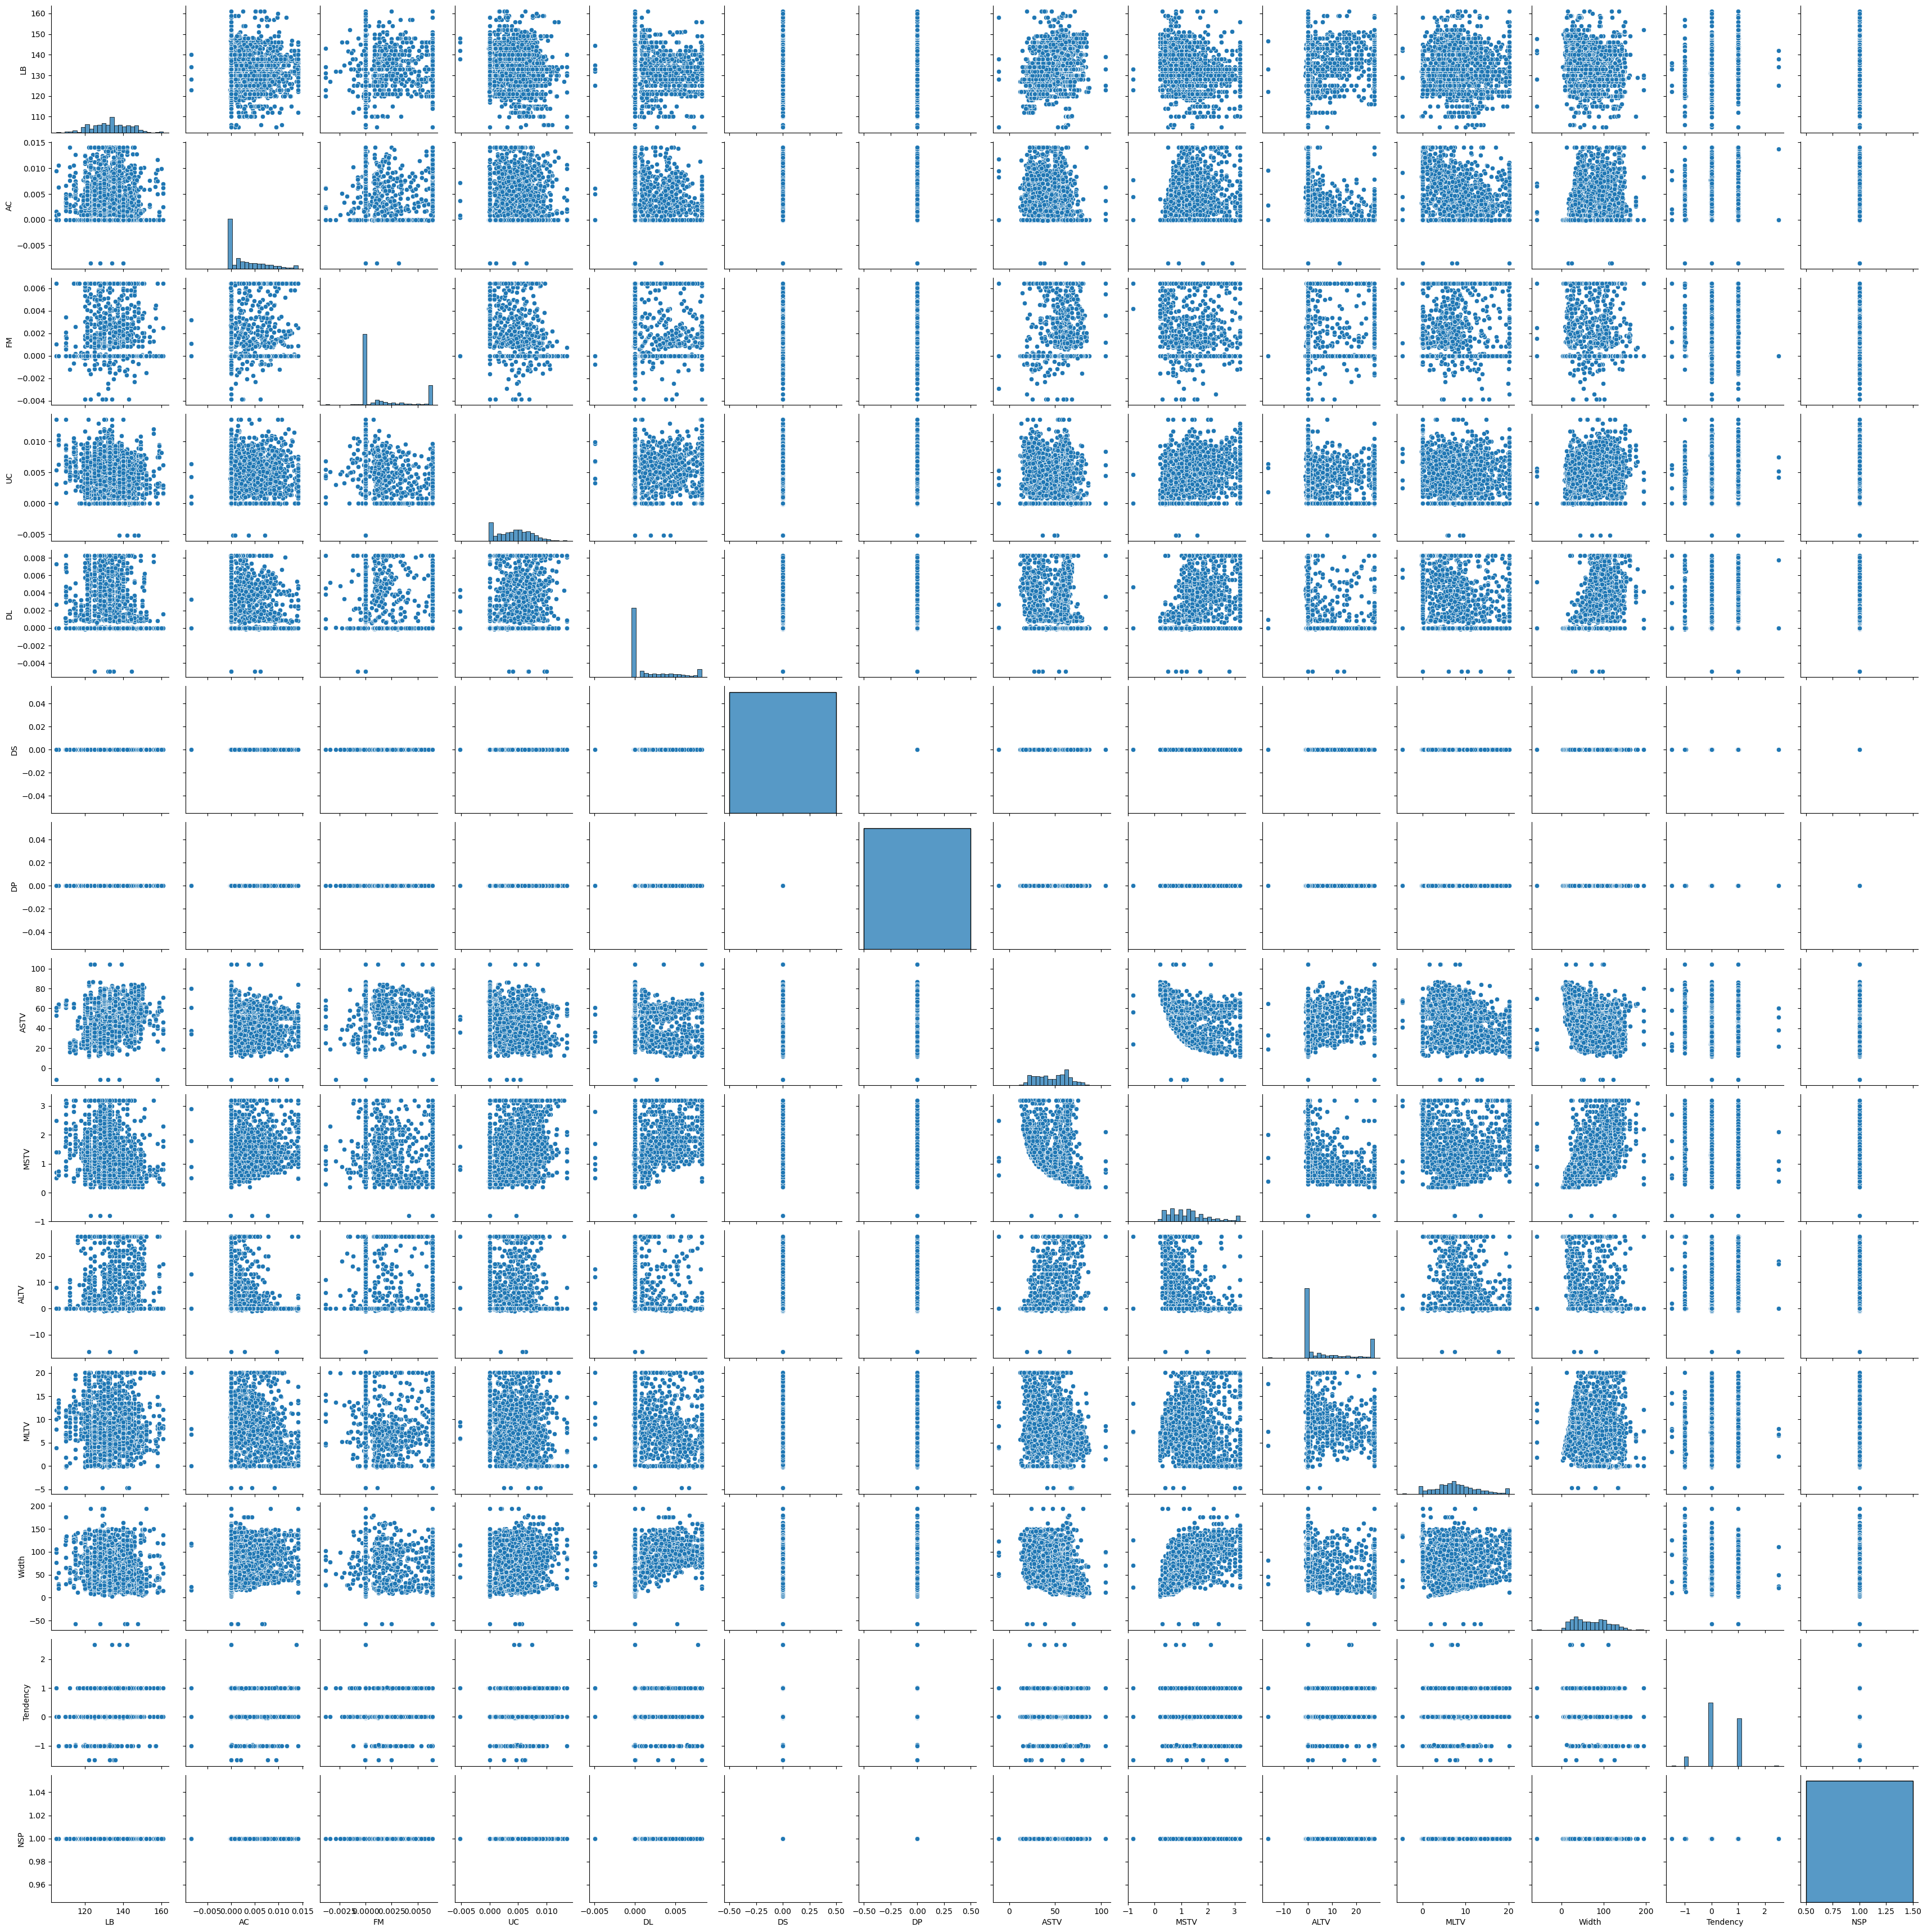

In [34]:
sns.pairplot(Data)

<Axes: >

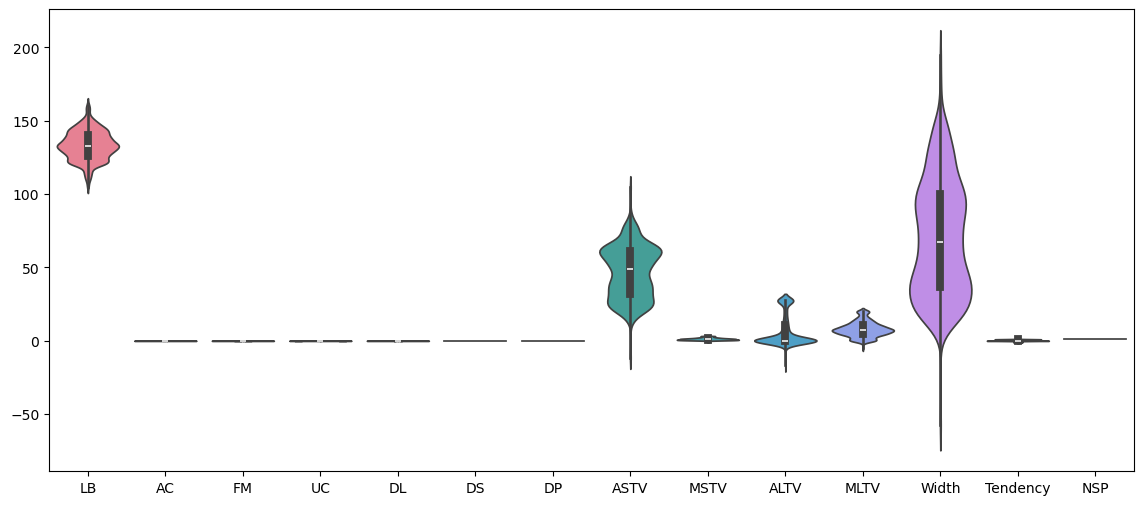

In [36]:
plt.figure(figsize=(14,6))
sns.violinplot(data=Data)

### 5.Conclusion Report